In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.layers import Dense
from keras import Sequential
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:\Ineuron Data Science\Data\Admission_Predict.csv")
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.2 KB


In [4]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [5]:
df.drop(columns=["Serial No."],inplace=True)

In [6]:
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0.82
396,325,107,3,3.0,3.5,9.11,1,0.84
397,330,116,4,5.0,4.5,9.45,1,0.91
398,312,103,3,3.5,4.0,8.78,0,0.67


In [7]:
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [8]:
x

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1
396,325,107,3,3.0,3.5,9.11,1
397,330,116,4,5.0,4.5,9.45,1
398,312,103,3,3.5,4.0,8.78,0


In [9]:
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
395    0.82
396    0.84
397    0.91
398    0.67
399    0.95
Name: Chance of Admit , Length: 400, dtype: float64

In [10]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=23)

In [11]:
scaler = MinMaxScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale  = scaler.fit_transform(X_test)

In [12]:
X_train_scale

array([[0.2       , 0.35714286, 0.5       , ..., 0.375     , 0.43910256,
        0.        ],
       [0.88      , 1.        , 1.        , ..., 1.        , 0.98397436,
        1.        ],
       [0.82      , 0.82142857, 1.        , ..., 0.625     , 0.82051282,
        1.        ],
       ...,
       [0.36      , 0.64285714, 0.5       , ..., 0.5       , 0.38461538,
        1.        ],
       [0.46      , 0.42857143, 0.5       , ..., 0.875     , 0.59294872,
        0.        ],
       [0.64      , 0.82142857, 1.        , ..., 0.875     , 0.82051282,
        1.        ]])

In [13]:
model = Sequential()
model.add(Dense(16,activation="relu",input_dim=7)) #2*n = 2*7
model.add(Dense(32,activation="relu"))
model.add(Dense(1,activation="linear"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                128       
                                                                 
 dense_1 (Dense)             (None, 32)                544       
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 705 (2.75 KB)
Trainable params: 705 (2.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [14]:
model.compile(loss="mean_squared_error",optimizer="SGD",metrics=['accuracy'])

In [15]:
history = model.fit(X_train_scale,y_train,validation_split=0.2,epochs=25)

Epoch 1/25
8/8 [==============================] - 0s 19ms/step - loss: 0.1322 - accuracy: 0.0000e+00 - val_loss: 0.0635 - val_accuracy: 0.0000e+00
Epoch 2/25
8/8 [==============================] - 0s 4ms/step - loss: 0.0546 - accuracy: 0.0000e+00 - val_loss: 0.0326 - val_accuracy: 0.0000e+00
Epoch 3/25
8/8 [==============================] - 0s 4ms/step - loss: 0.0319 - accuracy: 0.0000e+00 - val_loss: 0.0249 - val_accuracy: 0.0000e+00
Epoch 4/25
8/8 [==============================] - 0s 4ms/step - loss: 0.0247 - accuracy: 0.0000e+00 - val_loss: 0.0222 - val_accuracy: 0.0000e+00
Epoch 5/25
8/8 [==============================] - 0s 4ms/step - loss: 0.0214 - accuracy: 0.0000e+00 - val_loss: 0.0204 - val_accuracy: 0.0000e+00
Epoch 6/25
8/8 [==============================] - 0s 4ms/step - loss: 0.0193 - accuracy: 0.0000e+00 - val_loss: 0.0188 - val_accuracy: 0.0000e+00
Epoch 7/25
8/8 [==============================] - 0s 4ms/step - loss: 0.0177 - accuracy: 0.0000e+00 - val_loss: 0.0173 - va

In [16]:
y_pred = model.predict(X_test_scale)

3/3 [==============================] - 0s 1ms/step


In [17]:
r2_score(y_pred,y_test)

0.517230334548448

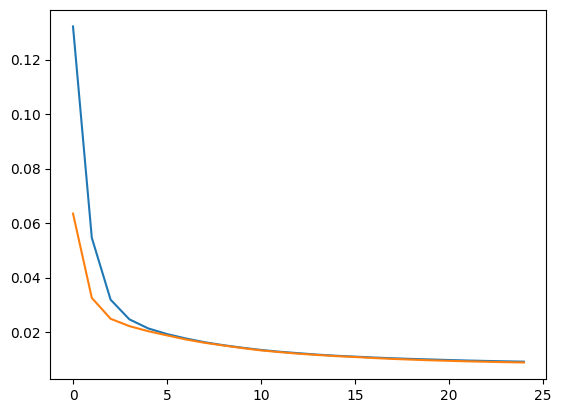

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [19]:
history.history

{'loss': [0.13216814398765564,
  0.054637085646390915,
  0.03192716836929321,
  0.024701952934265137,
  0.02138688415288925,
  0.019302695989608765,
  0.017692770808935165,
  0.016312483698129654,
  0.015225058421492577,
  0.014301522634923458,
  0.013479864224791527,
  0.0128158675506711,
  0.012283800169825554,
  0.011764300987124443,
  0.011352506466209888,
  0.011020911857485771,
  0.010697148740291595,
  0.010423758067190647,
  0.010183748789131641,
  0.009988242760300636,
  0.009782048873603344,
  0.009596399031579494,
  0.009438810870051384,
  0.009301195852458477,
  0.00917891040444374],
 'accuracy': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'val_loss': [0.06351959705352783,
  0.03257589414715767,
  0.024916619062423706,
  0.02221560664474964,
  0.020353510975837708,
  0.018823150545358658,
  0.017338085919618607,
  0.016103515401482582,
  0.0151